# Évaluation des Modèles

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.baselines import \
    AverageRegressor, LastWeekPersistenceRegressor, YesterdayPersistenceRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost.xgboost_regressor import XGBoostRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

Importing plotly failed. Interactive plots will not work.


In [2]:
evaluator = TimeSeriesEvaluator(df, "realistic")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start, True)

## 3. Modèles de Références

In [3]:
average_model = AverageRegressor()
evaluator.rolling_validation(average_model, df_train, df_val)

week_model = LastWeekPersistenceRegressor()
evaluator.rolling_validation(week_model, df_train, df_val)

yesterday_model = YesterdayPersistenceRegressor()
evaluator.rolling_validation(yesterday_model, df_train, df_val)

evaluator.grid_search_rolling_validation(
	SimilarDayRegressor,
	{
		"k": [4],
		"temp_weight": [100.0, 1000.0]
	},
	df_train, df_val
)

simple_lr_model = LinearRegressor(
	features_cols=[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]
)
evaluator.rolling_validation(simple_lr_model, df_train, df_val);

Évaluation de AverageRegressor | 8784 lignes | réentraînement/1ME | 13 itérations
Progression: 2024-12-31 00:00...
Score : MAE = 8481.31 MW |RMSE = 10282.61 MW |MAPE = 18.19%

Évaluation de LastWeekPersistenceRegressor | 8784 lignes | réentraînement/1ME | 13 itérations
Progression: 2024-12-31 00:00...
Score : MAE = 3229.23 MW |RMSE = 4845.62 MW |MAPE = 6.05%

Évaluation de YesterdayPersistenceRegressor | 8784 lignes | réentraînement/1ME | 13 itérations
Progression: 2024-12-31 00:00...
Score : MAE = 3182.98 MW |RMSE = 4362.14 MW |MAPE = 6.40%

Grid Search de SimilarDayRegressor avec 2 combinaisons de paramètres:

Combination 1/2 : {'k': 4, 'temp_weight': 100.0}
Évaluation de SimilarDayRegressor | 8784 lignes | réentraînement/1ME | 13 itérations
Progression: 2024-12-31 00:00...
Score : MAE = 2242.16 MW |RMSE = 3585.65 MW |MAPE = 4.15%

Combination 2/2 : {'k': 4, 'temp_weight': 1000.0}
Évaluation de SimilarDayRegressor | 8784 lignes | réentraînement/1ME | 13 itérations
Progression: 2024-1

## 4. Linear Regression

In [4]:
lr_model = LinearRegressor(
	features_cols=[
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
		'temperature_point_rosee_c_meme_heure_derniere_connue',
		'temperature_point_rosee_c_derniere_connue',
		'temperature_point_rosee_c_moins_365', 'temperature_point_rosee_c_moins_366'
	]
)
evaluator.rolling_validation(lr_model, df_train, df_val);

Évaluation de LinearRegressor | 8784 lignes | réentraînement/1ME | 13 itérations
Progression: 2024-12-31 00:00...
Score : MAE = 2019.43 MW |RMSE = 2638.93 MW |MAPE = 4.04%



## 5. Prophet

In [5]:
prophet_model = ProphetRegressor(features_cols=["degres_sous_15", "degres_au_dessus_22"])
evaluator.rolling_validation(prophet_model, df_train, df_val);

Évaluation de ProphetRegressor | 8784 lignes | réentraînement/1ME | 13 itérations


21:19:51 - cmdstanpy - INFO - Chain [1] start processing
21:20:06 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-01 00:00...

21:20:07 - cmdstanpy - INFO - Chain [1] start processing
21:20:37 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-31 00:00...

21:20:39 - cmdstanpy - INFO - Chain [1] start processing


KeyboardInterrupt: 

## 6. XGB

In [6]:
xgb_model = XGBoostRegressor()
evaluator.rolling_validation(xgb_model, df_train, df_val);

Évaluation de XGBoostRegressorCustom | 8784 lignes | réentraînement/1ME | 13 itérations

Nombre d'arbres réellement retenus (best_iteration) : 1375 / 3000
Meilleure MAE validation : 1746.65
Progression: 2024-01-01 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 1338 / 3000
Meilleure MAE validation : 2261.69
Progression: 2024-01-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 661 / 3000
Meilleure MAE validation : 1379.66
Progression: 2024-02-29 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 1003 / 3000
Meilleure MAE validation : 1469.71
Progression: 2024-03-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 750 / 3000
Meilleure MAE validation : 1574.27
Progression: 2024-04-30 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 1212 / 3000
Meilleure MAE validation : 1216.83
Progression: 2024-05-31 00:00...
Nombre d'arbres réellement retenus (best_iteration) : 575 / 3000
Meilleure MAE validation : 567.25
Progressio

## Visualisation

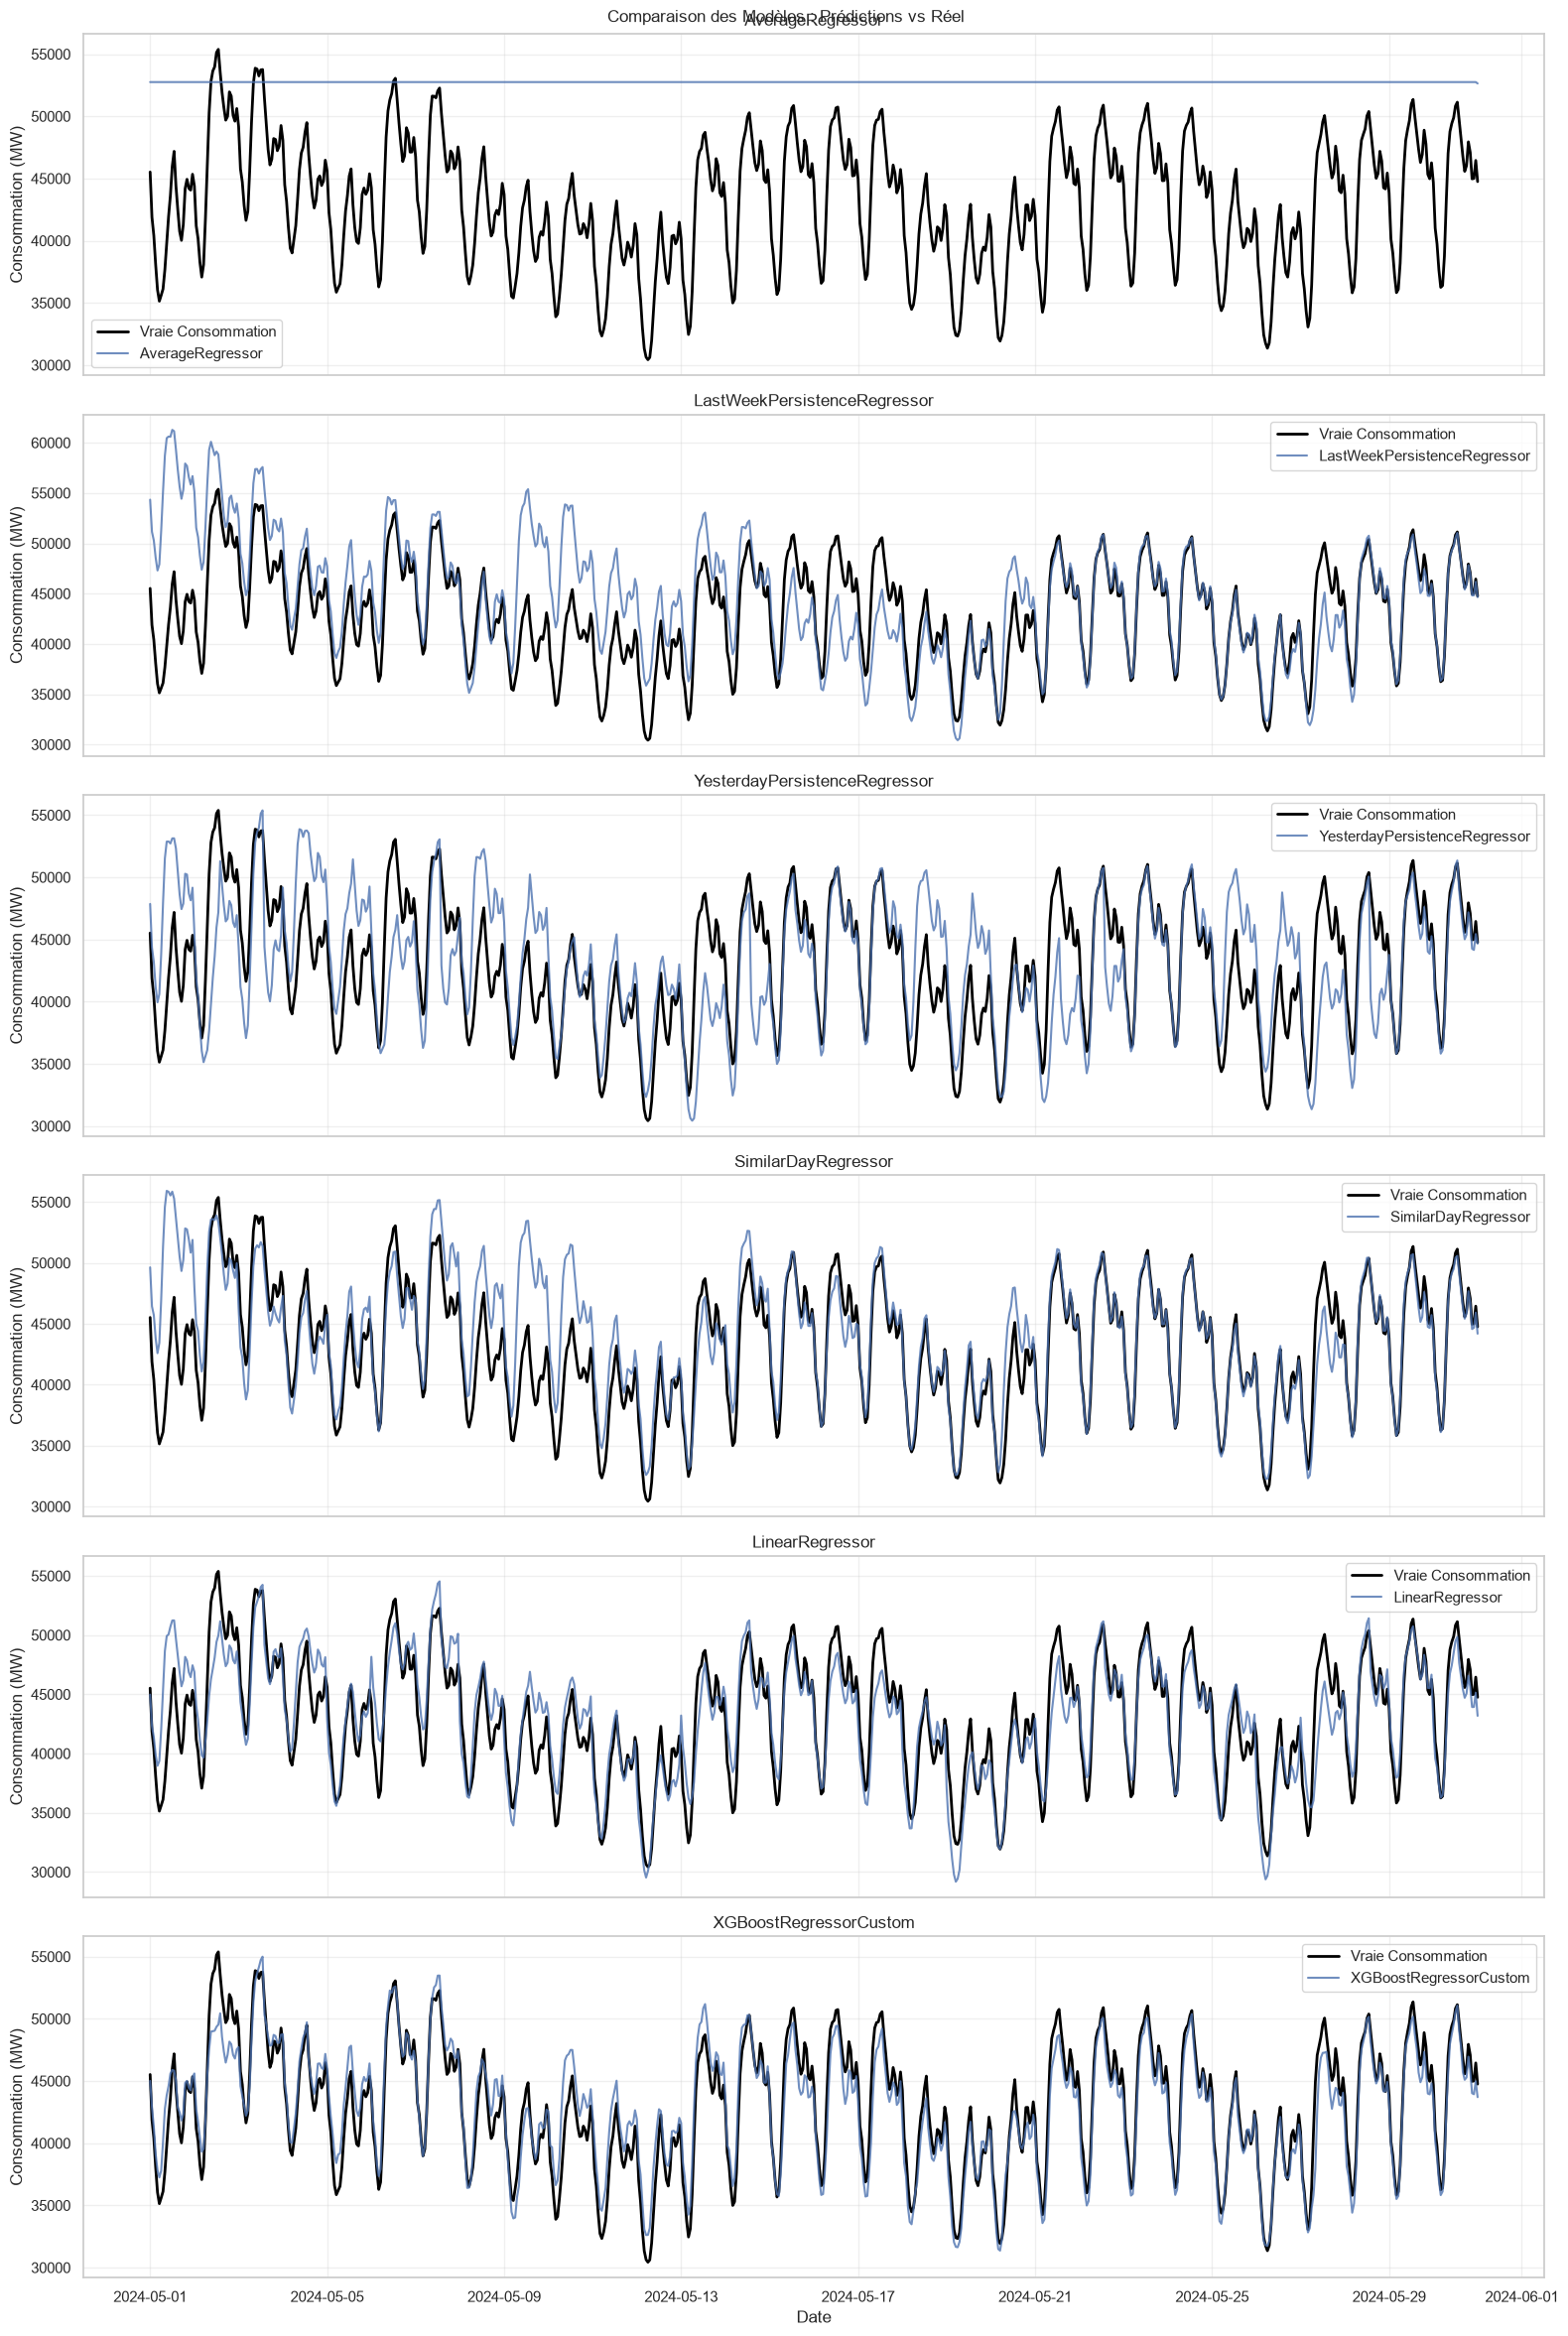

In [7]:
# Zoomons sur le mois de Mai 2024
start_zoom = pd.to_datetime('2024-05-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-05-31').tz_localize('Europe/Paris')

evaluator.plot_predictions(df_val, start_date=start_zoom, end_date=end_zoom)

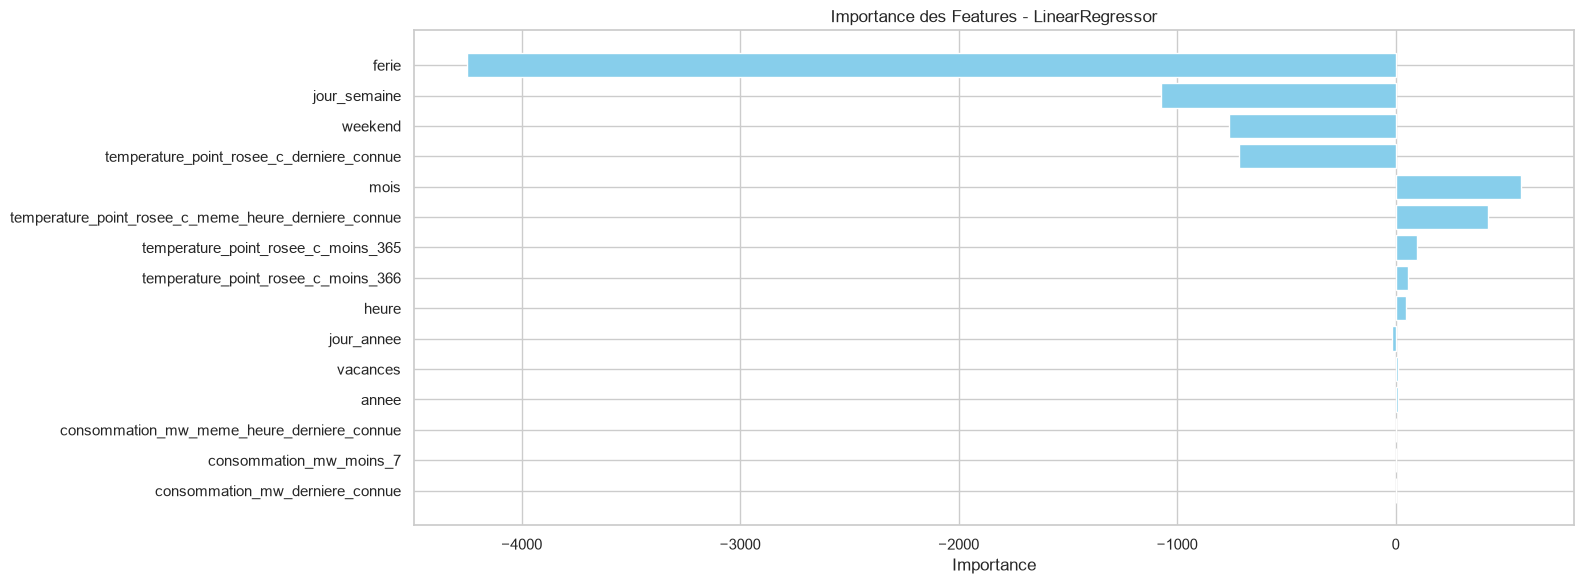

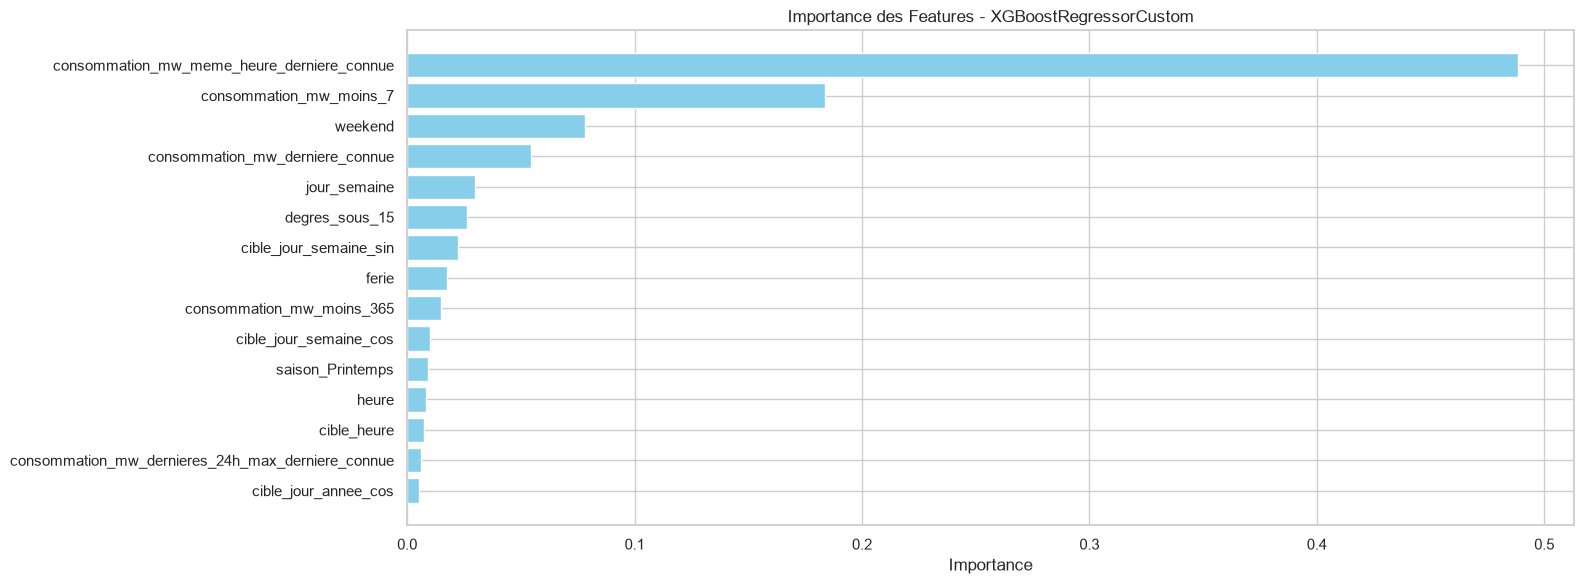

In [8]:
evaluator.plot_feature_importances(top_n=15)

e:\Projects\Studies\ElectricityConsumption\src\models\baselines.py:106: RuntimeWarning: Mean of empty slice
  mean_temp_j = np.nanmean(compare_hours[col_temp].values)


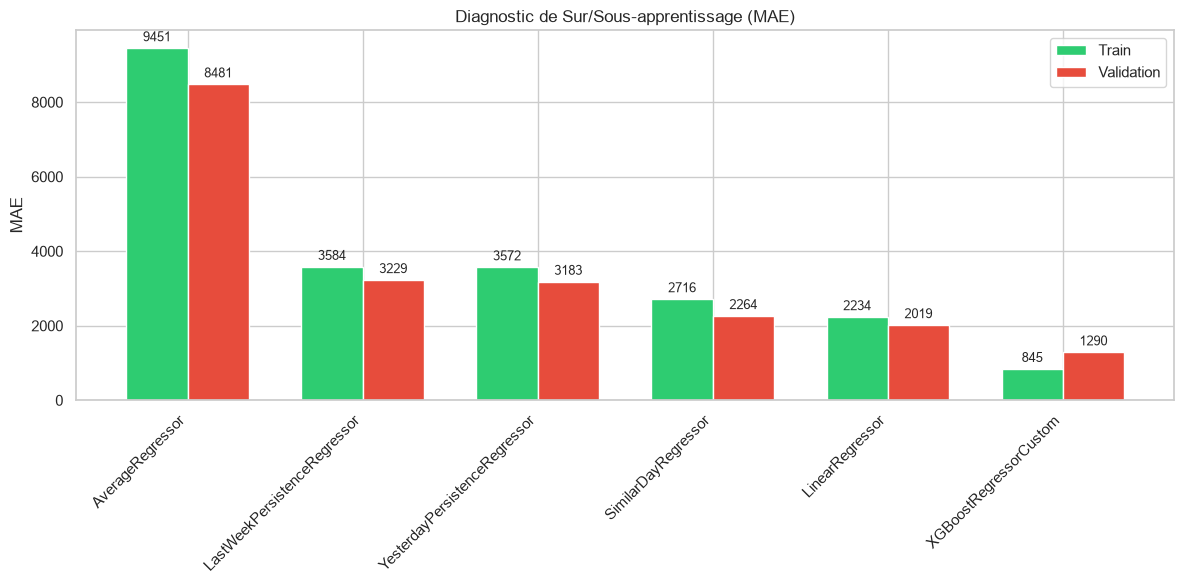

In [9]:
evaluator.plot_train_val_metrics(df_train)